<a href="https://colab.research.google.com/github/Shakib-IO/INSE_6220_Lab_Winter_2023/blob/main/PCA_on_Diagnosis_of_Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Principal Component Analysis and diagnosis of Breast cancer**

**Install Pycaret**

In [ ]:
!pip install pycaret==2.3.6
print(python.__version__)

**Import Libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")
import pandas as pd
plt.rcParams['figure.figsize'] = (7,5)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
print("Pandas version: ", pd.__version__)
print("Seaborn version: ", sns.__version__)

Pandas version:  1.3.5
Seaborn version:  0.11.2


**Dataset**

The “Breast Cancer diagnosis Data Set” used for Principle Component Analysis (PCA) and classification models is obtained from Kaggle. The data set provided information about tumor attributes to diagnosed it as benign or malignant for breast cancer.

There are 5 attributes with 569 entries and one column for classification. 
**0 represents Benign and 1 represents Malignant.**


All attributes are numerical and they are listed bellow:

1. mean_radius = MR
2. mean_texture = MT
3. mean_perimeter = MP
4. mean_area = MA
5. mean_smoothness = MS
6. diagnosis (Label)

The original dataset can be found on below link:
https://www.kaggle.com/datasets/theodoravalerie/breast-cancer-data





In [ ]:
#read cvs file into dataframe
df = pd.read_csv('https://raw.githubusercontent.com/shreya201/INSE6220_40208796/main/Breast_cancer_data.csv')
df.head(25)

,MR,MT,MP,MA,MS,diagnosis
0,17.990,10.38,122.80,1001.0,0.11840,0
1,20.570,17.77,132.90,1326.0,0.08474,0
2,19.690,21.25,130.00,1203.0,0.10960,0
3,11.420,20.38,77.58,386.1,0.14250,0
4,20.290,14.34,135.10,1297.0,0.10030,0
5,12.450,15.70,82.57,477.1,0.12780,0
6,18.250,19.98,119.60,1040.0,0.09463,0
7,13.710,20.83,90.20,577.9,0.11890,0
8,13.000,21.82,87.50,519.8,0.12730,0
9,12.460,24.04,83.97,475.9,0.11860,0


In [ ]:
len(df.index)

569

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MR         569 non-null    float64
 1   MT         569 non-null    float64
 2   MP         569 non-null    float64
 3   MA         569 non-null    float64
 4   MS         569 non-null    float64
 5   diagnosis  569 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.8 KB


In [ ]:
print("Number of duplicated rows is: ", df.duplicated().sum())

Number of duplicated rows is:  0


In [ ]:
print("Number of rows with NaNs is: ", df.isna().any(axis=1).sum())

Number of rows with NaNs is:  0


**Exploratory Data Analysis**

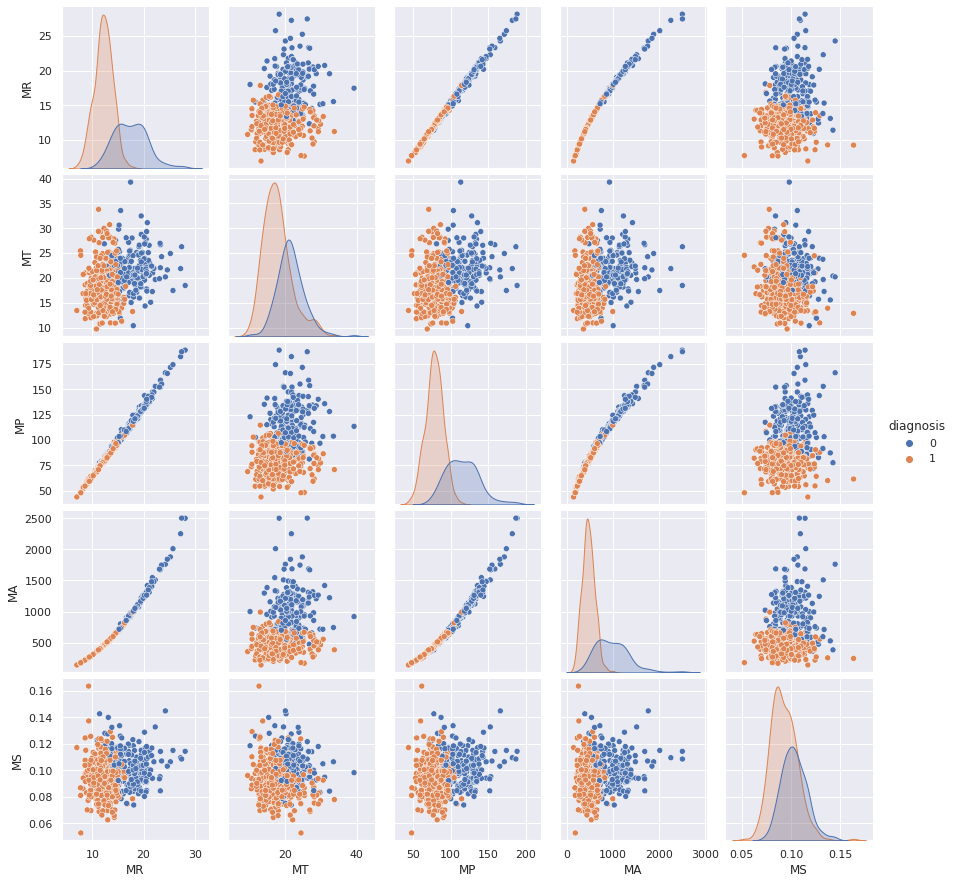

In [ ]:
sns.pairplot(df, hue='diagnosis')
plt.show()

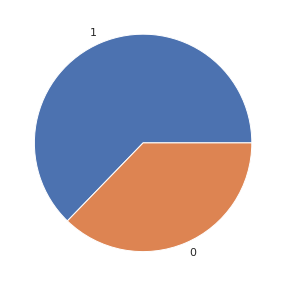

In [ ]:
y =df['diagnosis']
y.value_counts().plot(kind='pie')
plt.ylabel('')
plt.show()

**Data Matrix**

In [ ]:
X = df.drop(columns=['diagnosis'])
X.head(10)

,MR,MT,MP,MA,MS
0,17.99,10.38,122.80,1001.0,0.11840
1,20.57,17.77,132.90,1326.0,0.08474
2,19.69,21.25,130.00,1203.0,0.10960
3,11.42,20.38,77.58,386.1,0.14250
4,20.29,14.34,135.10,1297.0,0.10030
5,12.45,15.70,82.57,477.1,0.12780
6,18.25,19.98,119.60,1040.0,0.09463
7,13.71,20.83,90.20,577.9,0.11890
8,13.00,21.82,87.50,519.8,0.12730
9,12.46,24.04,83.97,475.9,0.11860


In [ ]:
X.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MR,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
MT,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
MP,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
MA,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
MS,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634


**Standardize the Data**

In [ ]:
Xs = StandardScaler().fit_transform(X)
Xcols = X.columns
X = pd.DataFrame(Xs)
X.columns = Xcols
X.head(10)

,MR,MT,MP,MA,MS
0,1.097064,-2.073335,1.269934,0.984375,1.568466
1,1.829821,-0.353632,1.685955,1.908708,-0.826962
2,1.579888,0.456187,1.566503,1.558884,0.942210
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553
4,1.750297,-1.151816,1.776573,1.826229,0.280372
5,-0.476375,-0.835335,-0.387148,-0.505650,2.237421
6,1.170908,0.160649,1.138125,1.095295,-0.123136
7,-0.118517,0.358450,-0.072867,-0.218965,1.604049
8,-0.320167,0.588830,-0.184080,-0.384207,2.201839
9,-0.473535,1.105439,-0.329482,-0.509063,1.582699


In [ ]:
X.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MR,569.0,-1.256562e-16,1.00088,-2.029648,-0.689385,-0.215082,0.469393,3.971288
MT,569.0,1.049736e-16,1.00088,-2.229249,-0.725963,-0.104636,0.584176,4.651889
MP,569.0,-1.272171e-16,1.00088,-1.984504,-0.691956,-0.235980,0.499677,3.976130
MA,569.0,-1.900452e-16,1.00088,-1.454443,-0.667195,-0.295187,0.363507,5.250529
MS,569.0,-8.226187e-16,1.00088,-3.112085,-0.710963,-0.034891,0.636199,4.770911


**Observations and variables**

In [ ]:
observations = list(df.index)
variables = list(df.columns)

**Box and Whisker Plots**

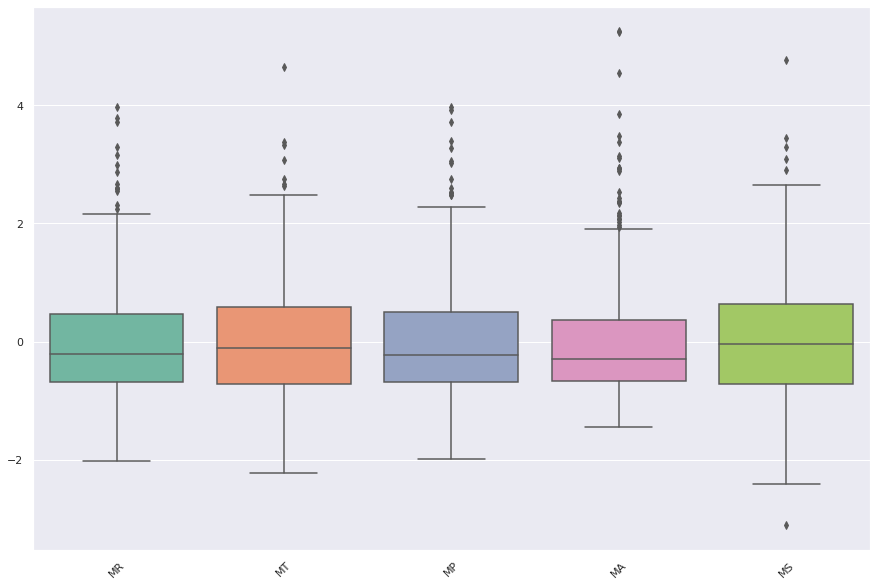

In [ ]:
ax = plt.figure(figsize=(15,10))
ax = sns.boxplot(data=X, orient="v", palette="Set2")
ax.set_xticklabels(ax.get_xticklabels(),rotation=45);

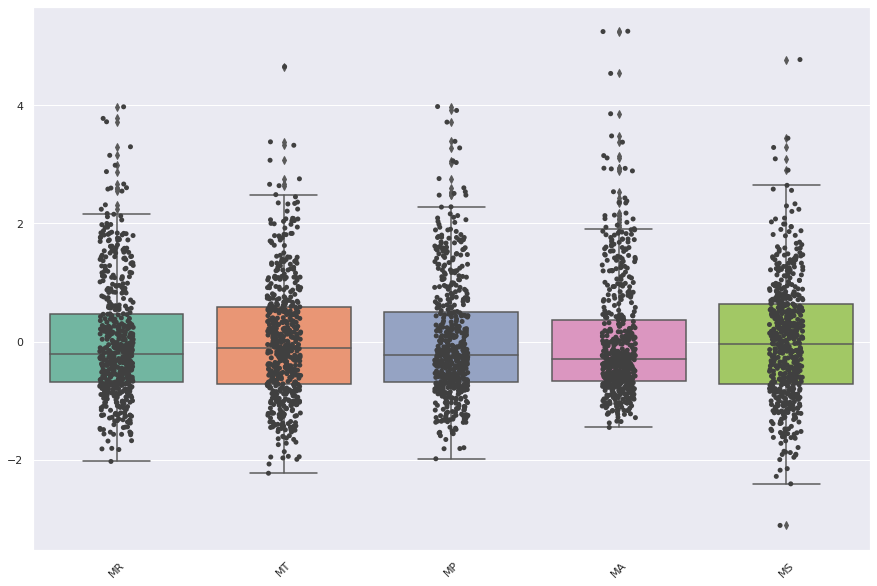

In [ ]:
# Use swarmplot() or stripplot to show the datapoints on top of the boxes:
#plt. figure()

ax = plt.figure(figsize=(15,10))    
ax = sns.boxplot(data=X, orient="v", palette="Set2")
ax = sns.stripplot(data=X, color=".25") 
ax.set_xticklabels(ax.get_xticklabels(),rotation=45);

**Correlation Matrix**

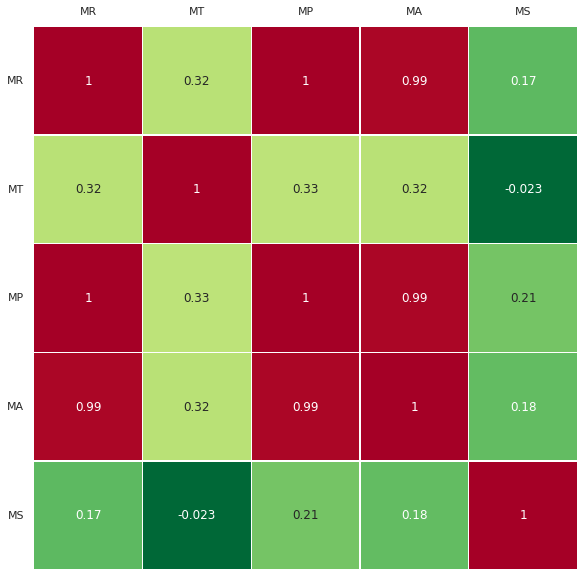

In [ ]:
fig1,ax1 = plt.subplots(figsize=(15,10))
ax = sns.heatmap(X.corr(), cmap='RdYlGn_r', linewidths=0.3, annot=True, cbar=False, square=True)
plt.yticks(rotation=0)
ax.tick_params(labelbottom=False,labeltop=True)
ax.set_xticklabels(ax.get_xticklabels(),rotation=0);

#X.corr().style.background_gradient(cmap='coolwarm').set_precision(2)
#sns.clustermap(X.corr(), annot=True, fmt='.2f')

# **Principal Component Analysis (PCA)**

Text(0, 0.5, '$Z_2$')

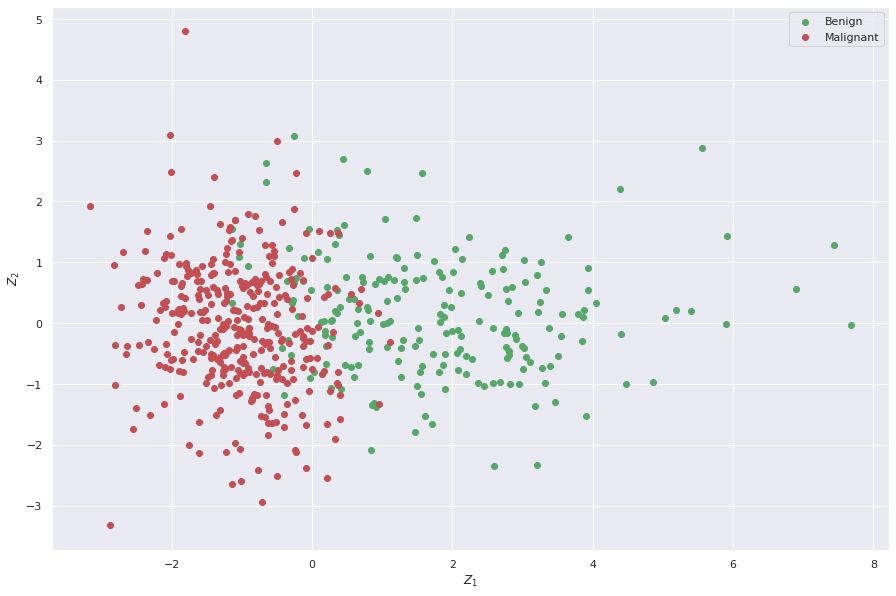

In [ ]:
pca = PCA()
Z = pca.fit_transform(X)

# (Malignant)->1,  (Benign)->0

idx_Benign= np.where(y == 0)
idx_Malignant = np.where(y == 1)


plt. figure(figsize=(15,10))
plt.scatter(Z[idx_Benign,0], Z[idx_Benign,1], c='g', label='Benign')
plt.scatter(Z[idx_Malignant,0], Z[idx_Malignant,1], c='r', label='Malignant')


plt.legend()
plt.xlabel('$Z_1$')
plt.ylabel('$Z_2$')

**Eigenvectors**

array([[ 0.55371341, -0.0026939 , -0.17451457, -0.3987202 , -0.70990216],
       [ 0.24687793, -0.53356361,  0.80887797,  0.00514554, -0.00714976],
       [ 0.55562001,  0.02473754, -0.14438462, -0.41807654,  0.70359047],
       [ 0.55179039,  0.00385895, -0.17093468,  0.81614814,  0.01400078],
       [ 0.1388039 ,  0.84538499,  0.51497137,  0.01048524, -0.02742701]])

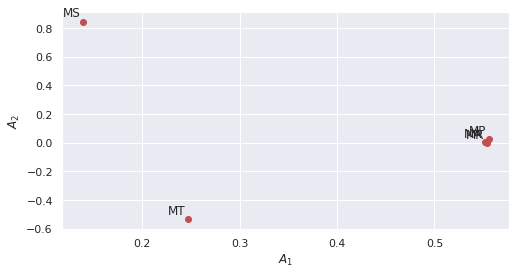

In [ ]:
A = pca.components_.T 
plt. figure(figsize=(8,4))

plt.scatter(A[:,0],A[:,1],c='r')
plt.xlabel('$A_1$')
plt.ylabel('$A_2$')
for label, x, y in zip(variables, A[:, 0], A[:, 1]):
  plt.annotate(label, xy=(x, y), xytext=(-2, 2), textcoords='offset points', ha='right', va='bottom')
A

/usr/local/lib/python3.7/dist-packages/matplotlib/collections.py:885: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


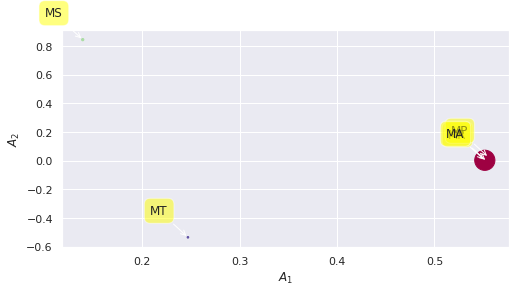

In [ ]:
plt. figure(figsize=(8,4))
plt.scatter(A[:, 0],A[:, 1], marker='o', c=A[:, 2], s=A[:, 3]*500, cmap=plt.get_cmap('Spectral'))
plt.xlabel('$A_1$')
plt.ylabel('$A_2$')
for label, x, y in zip(variables,A[:, 0],A[:, 1]):
  plt.annotate(label,xy=(x, y), xytext=(-20, 20),
      textcoords='offset points', ha='right', va='bottom',
      bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5),
      arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))

**Scree plot**

array([3.17792638e+00, 1.02288918e+00, 7.89967999e-01, 1.66216545e-02,
       1.39760342e-03])

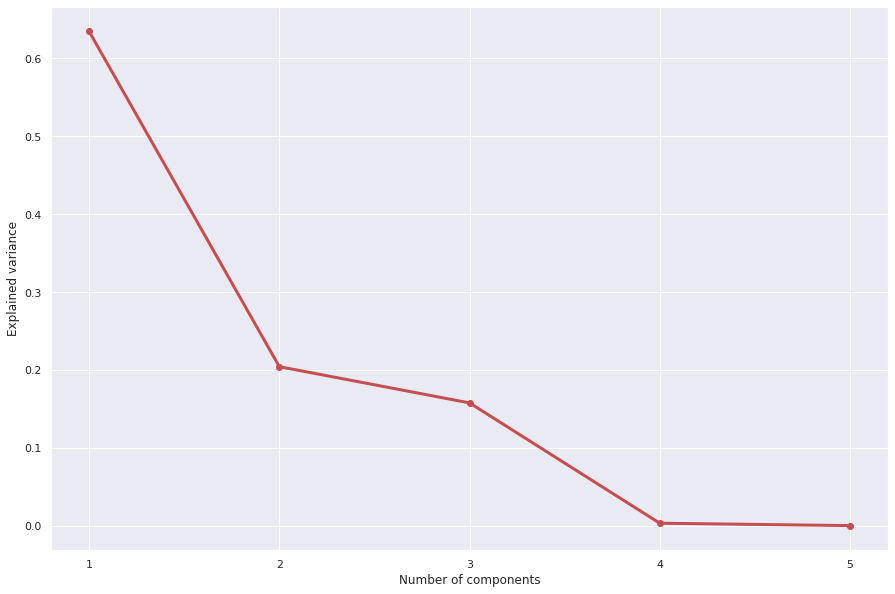

In [ ]:
#Eigenvalues
Lambda = pca.explained_variance_ 

#Scree plot
x = np.arange(len(Lambda)) + 1
plt. figure(figsize=(15,10))
plt.plot(x,Lambda/sum(Lambda), 'ro-', lw=3)
plt.xticks(x, [""+str(i) for i in x], rotation=0)
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
Lambda

**Explained Variance**

Text(0, 0.5, 'Cumulative explained variance')

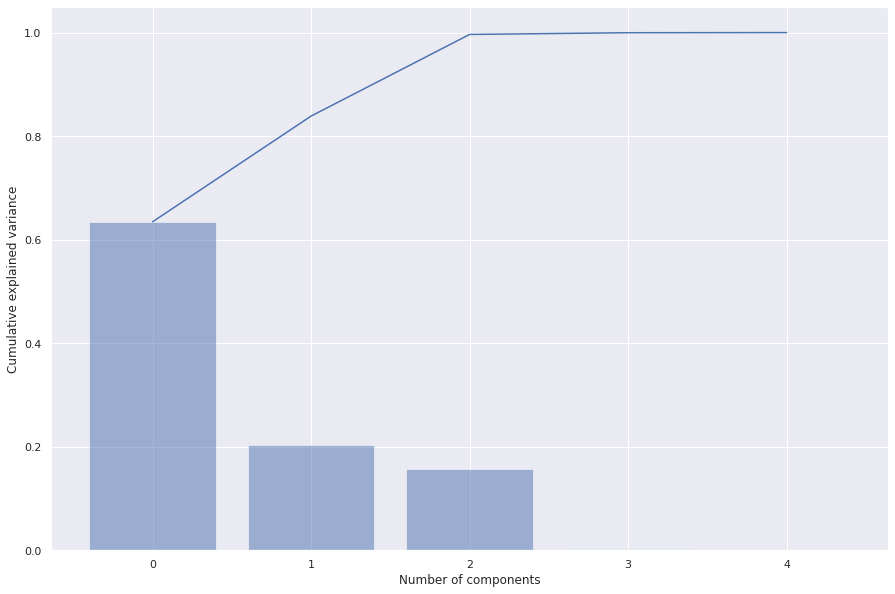

In [ ]:
ell = pca.explained_variance_ratio_
ind = np.arange(len(ell))
plt. figure(figsize=(15,10))
plt.bar(ind, ell, align='center', alpha=0.5)
plt.plot(np.cumsum(ell))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')

**Biplot**

array([ 2.46447230e+00, -4.66273649e-01,  5.93636816e-01,  2.62494433e+00,
        8.97869701e-01,  2.32694200e+00, -1.60587424e-01,  1.16245480e+00,
        1.54204947e+00,  7.39329121e-01, -1.33977250e+00,  2.30259735e-01,
       -5.79158287e-01, -1.30962925e+00,  5.95955932e-01,  3.54110560e-02,
        3.73420592e-02,  1.08558317e+00, -1.96808056e-01,  6.92981681e-01,
        1.10751456e+00,  1.18096902e+00,  1.29300396e+00, -5.41883582e-01,
        7.06573042e-01,  1.72179087e+00,  2.70765649e-01, -2.05084380e-01,
       -1.96578529e-02,  6.77464440e-01, -8.39042573e-02,  9.33047597e-01,
        8.43491553e-01, -9.94695459e-01,  6.50104702e-01, -2.82448703e-01,
       -1.87917059e-01, -2.95032688e-01, -8.80212201e-01,  1.21027075e-01,
       -1.17756787e+00,  1.30770129e+00, -9.81178489e-01,  3.37379945e-01,
       -2.73321800e-01,  1.05786597e+00, -3.60594817e-01,  1.24102549e+00,
        9.69176162e-01, -9.11325246e-01, -9.06155186e-01, -8.12929986e-01,
       -7.14197069e-01,  

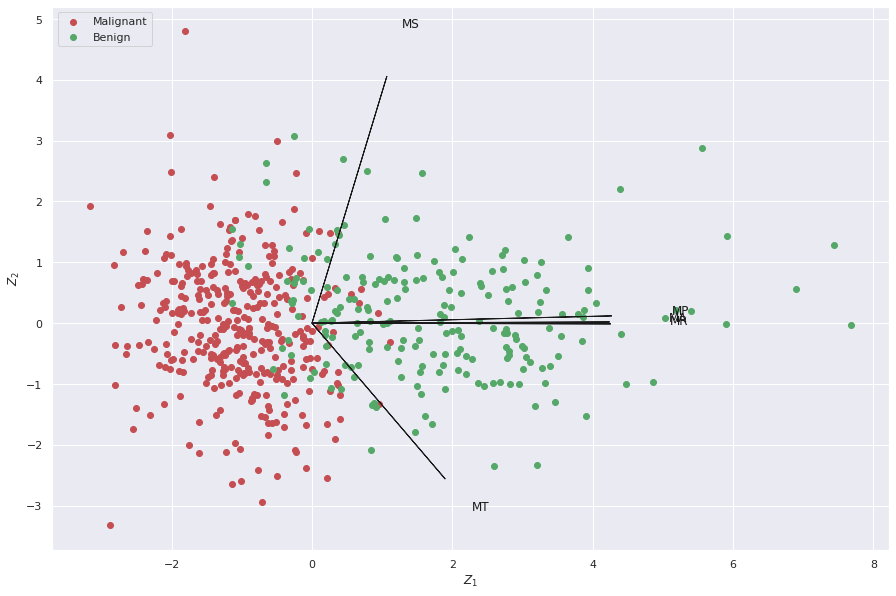

In [ ]:
# 0,1 denote PC1 and PC2; change values for other PCs
A1 = A[:,0] 
A2 = A[:,1]
Z1 = Z[:,0] 
Z2 = Z[:,1]

plt. figure(figsize=(15,10))
plt.xlabel('$Z_1$')
plt.ylabel('$Z_2$')
for i in range(len(A1)):
# arrows project features as vectors onto PC axes
  plt.arrow(0, 0, A1[i]*max(Z1), A2[i]*max(Z2), color='k', width=0.0005, head_width=0.0025)
  plt.text(A1[i]*max(Z1)*1.2, A2[i]*max(Z2)*1.2,variables[i], color='k')

plt.scatter(Z[idx_Malignant,0], Z[idx_Malignant,1], c='r', label='Malignant')
plt.scatter(Z[idx_Benign,0], Z[idx_Benign,1], c='g', label='Benign')

plt.legend(loc='upper left')
Z1
Z2

# **Using PCA Library**

In [ ]:
!pip install pca

  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9675 sha256=3d247bcd97a0fc867086e407c05a9754e91d2d993269d4eb72e7c6940253621d
  Stored in directory: /root/.cache/pip/wheels/a1/b6/7c/0e63e34eb06634181c63adacca38b79ff8f35c37e3c13e3c02
Successfully built wget


In [ ]:
from pca import pca
# Initialize and keep all PCs
model = pca()
# Fit transform
out = model.fit_transform(X)

[pca] >Processing dataframe..
[pca] >The PCA reduction is performed to capture [95.0%] explained variance using the [5] columns of the input data.
[pca] >Fit using PCA.
[pca] >Compute loadings and PCs.
[pca] >Compute explained variance.
[pca] >Number of components is [3] that covers the [95.00%] explained variance.
[pca] >The PCA reduction is performed on the [5] columns of the input dataframe.
[pca] >Fit using PCA.
[pca] >Compute loadings and PCs.
[pca] >Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[3]
[pca] >Outlier detection using SPE/DmodX with n_std=[2]


**Principal Components**

In [ ]:
out['PC']

,PC1,PC2,PC3
0,1.562077,2.464472,-1.412436
1,2.801064,-0.466274,-1.600928
2,2.848768,0.593637,0.085851
3,-0.658477,2.624944,2.246609
4,2.718517,0.897870,-1.661423
...,...,...,...
564,3.929944,0.550143,0.053511
565,3.322039,-0.983901,0.913880
566,1.469870,-1.784997,0.903319
567,3.865523,0.093999,1.771963


**Scatter plot**

(<Figure size 1440x1080 with 1 Axes>,
 <matplotlib.axes._subplots.AxesSubplot at 0x7f59621b57d0>)

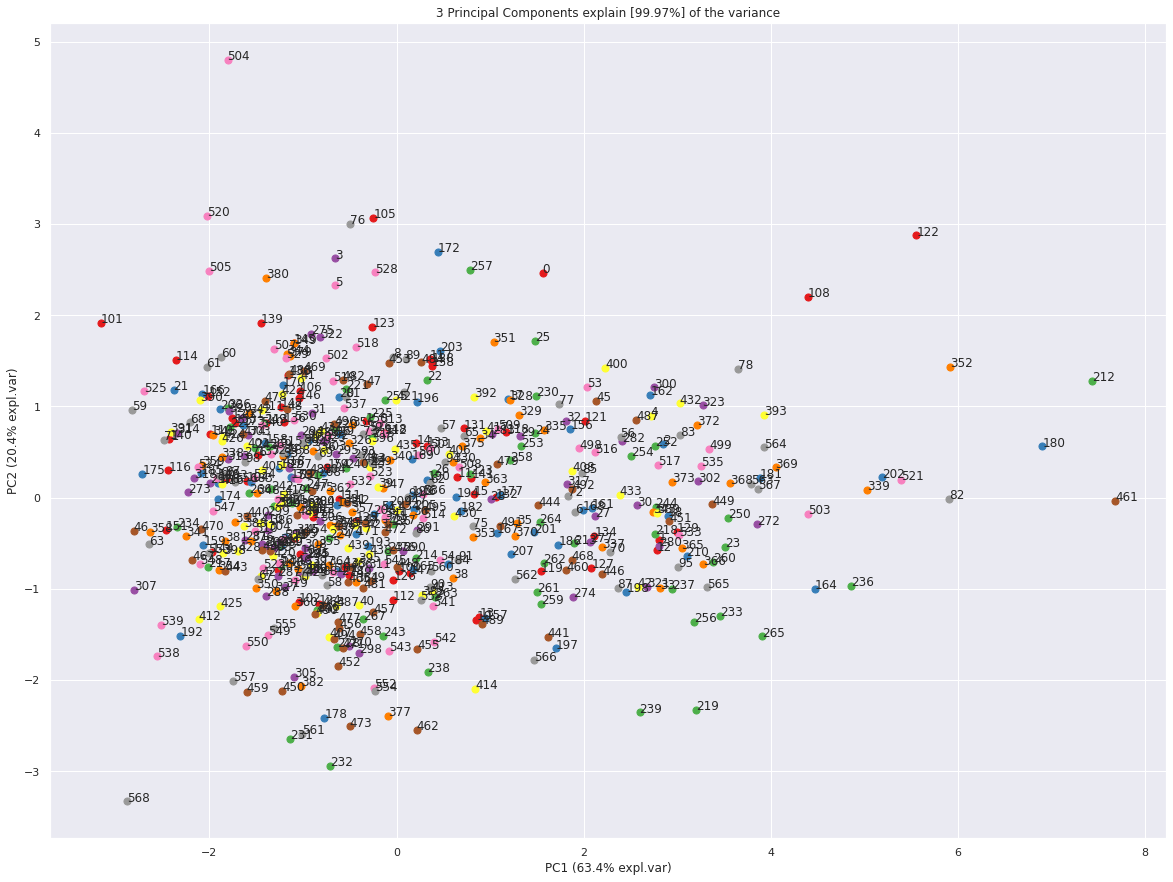

In [ ]:
model.scatter(label=True, legend=False)

**Eigenvectors**

In [ ]:
A = out['loadings'].T
A

,PC1,PC2,PC3
MR,0.553713,-0.002694,-0.174515
MT,0.246878,-0.533564,0.808878
MP,0.555620,0.024738,-0.144385
MA,0.551790,0.003859,-0.170935
MS,0.138804,0.845385,0.514971


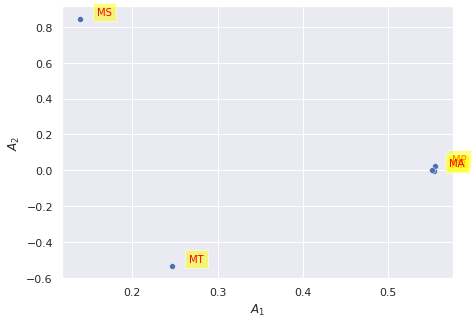

In [ ]:
sns.scatterplot(data=A, x="PC1", y="PC2")
plt.xlabel('$A_1$')
plt.ylabel('$A_2$')
for i in range(A.shape[0]):
 plt.text(x=A.PC1[i]+0.02,y=A.PC2[i]+0.02, s=variables[i],
          fontdict=dict(color='red',size=10),
          bbox=dict(facecolor='yellow',alpha=0.5))
 

**Scree Plot**

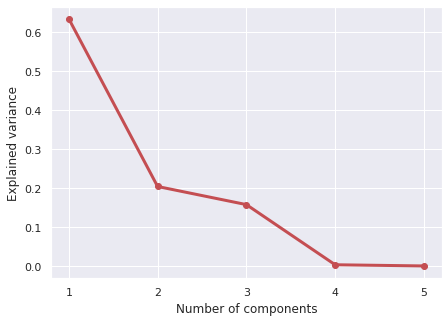

In [ ]:
VR = out['variance_ratio']
x = np.arange(len(VR)) + 1
plt.plot(x, VR, 'ro-', lw=3)
plt.xticks(x, [""+str(i) for i in x], rotation=0)
plt.xlabel('Number of components')
plt.ylabel('Explained variance') 
plt.show()

**Explained Variance Plot**

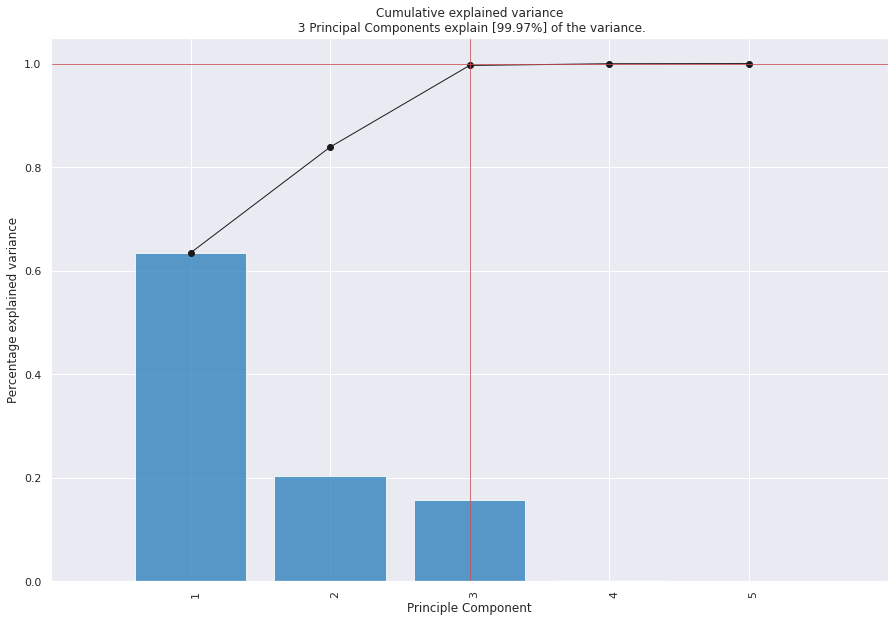

<Figure size 504x360 with 0 Axes>

In [ ]:
model.plot();

**Biplot**

[pca] >Plot PC1 vs PC2 with loadings.


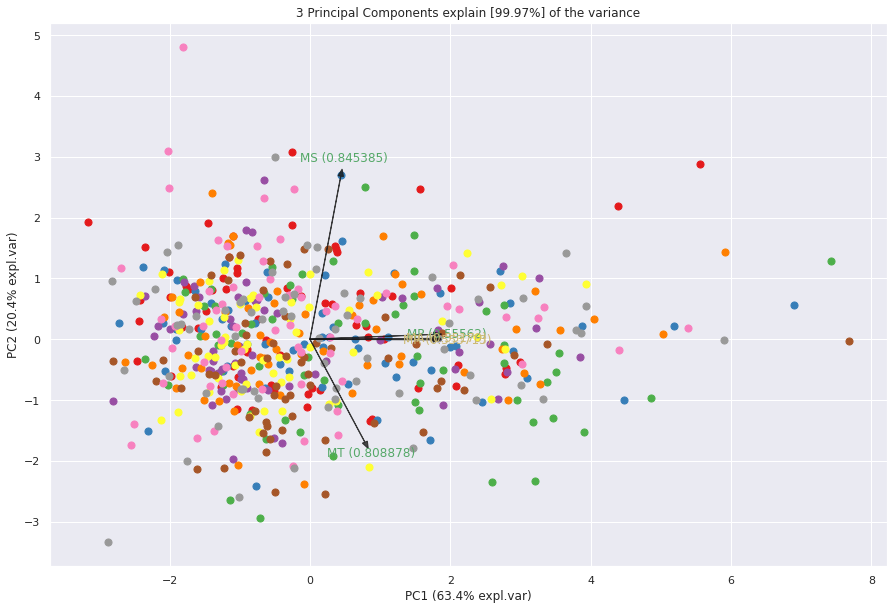

(<Figure size 1080x720 with 1 Axes>,
 <matplotlib.axes._subplots.AxesSubplot at 0x7f59623f9750>)

In [ ]:
model.biplot(label=False, legend=False, color_arrow='k')

[pca] >Plot PC1 vs PC2 vs PC3 with loadings.


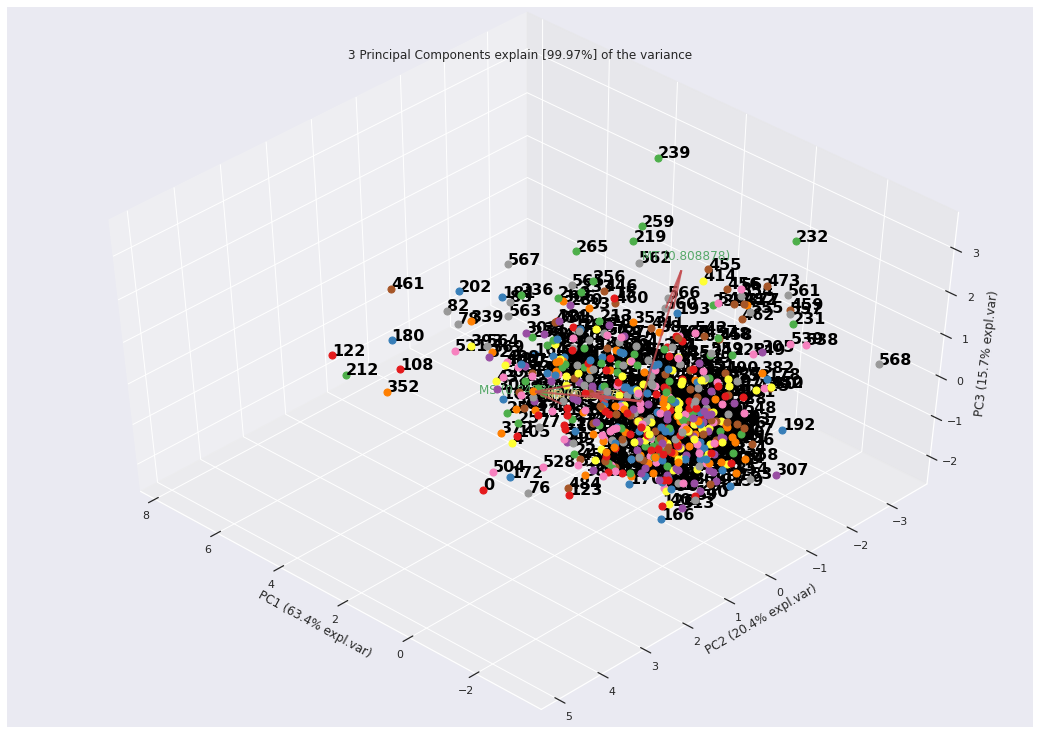

(<Figure size 1080x720 with 2 Axes>,
 <mpl_toolkits.mplot3d.axes3d.Axes3D at 0x7f5962320e50>)

In [ ]:
model.biplot3d(legend=False)

# Classification using Pycaret
At first dataset is split into train and test set with 70% and 30% ratio respectively. Then using the PyCaret compare_models() function, the models which shows the highest accuracy on the original dataset can be found. 
Before applying PCA, the output from compare_models() function shows that Linear Discriminant Analayis, Extra Trees Classifier, and Gradient Boosting Classifier shows the best performance.

 However, after applying PCA, the these models performance decreases and Logistic Regression, K-nearest neighbour, and Quadratic Discriminant Analysis shows the highest performance. Therefore, I have taken Logistic Regression, K-nearest Neighbour and Quadratic discriminant Analysis as my classification algorithms and applied these three models on the original dataset before applying PCA and after applying PCA.

In [ ]:
#Run the below code in your notebook to check the installed version
from pycaret.utils import version
version()

'2.3.6'

In [ ]:
#For Google Colab only
from pycaret.utils import enable_colab 
enable_colab()

Colab mode enabled.


In [ ]:
data = df.sample(frac=0.9, random_state=786)
data_unseen = df.drop(data.index)
#dr = df.drop(columns=['id'])

data.reset_index(drop=True, inplace=True)
data_unseen.reset_index(drop=True, inplace=True)

print('Data for Modeling: ' + str(data.shape))
print('Unseen Data For Predictions: ' + str(data_unseen.shape))

Data for Modeling: (512, 6)
Unseen Data For Predictions: (57, 6)


In [ ]:
from pycaret.classification import *
clf = setup(data=data, target='diagnosis', train_size=0.7, session_id=123)

,Description,Value
0,session_id,123
1,Target,diagnosis
2,Target Type,Binary
3,Label Encoded,None
4,Original Data,"(512, 6)"
5,Missing Values,False
6,Numeric Features,5
7,Categorical Features,0
8,Ordinal Features,False
9,High Cardinality Features,False


**Comparing All Models**

In [ ]:
#show the best model and their statistics
best_model = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.9329,0.9843,0.9814,0.9193,0.9472,0.8553,0.8662,0.010
et,Extra Trees Classifier,0.9190,0.9769,0.9587,0.9180,0.9356,0.8262,0.8358,0.411
gbc,Gradient Boosting Classifier,0.9133,0.9732,0.9398,0.9216,0.9292,0.8170,0.8217,0.075
qda,Quadratic Discriminant Analysis,0.9131,0.9754,0.9766,0.8952,0.9323,0.8118,0.8244,0.011
lightgbm,Light Gradient Boosting Machine,0.9107,0.9803,0.9307,0.9263,0.9267,0.8118,0.8163,0.057
rf,Random Forest Classifier,0.9106,0.9772,0.9398,0.9179,0.9267,0.8113,0.8175,0.449
ada,Ada Boost Classifier,0.9079,0.9683,0.9305,0.9226,0.9240,0.8060,0.8127,0.081
dt,Decision Tree Classifier,0.9049,0.8931,0.9491,0.9052,0.9246,0.7955,0.8037,0.011
lr,Logistic Regression,0.8967,0.9692,0.9262,0.9103,0.9158,0.7814,0.7883,0.261
ridge,Ridge Classifier,0.8967,0.0000,0.9494,0.8926,0.9173,0.7792,0.7911,0.010


In [ ]:
best_model

LinearDiscriminantAnalysis(n_components=None, priors=None, shrinkage=None,
                           solver='svd', store_covariance=False, tol=0.0001)

 Create a Model

**Logistic Regresssion**

In [ ]:
lr = create_model('lr')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8333,0.9708,0.9545,0.8077,0.8750,0.6301,0.6502
1,0.8056,0.9123,0.8636,0.8261,0.8444,0.5855,0.5866
2,0.8889,0.9351,0.9091,0.9091,0.9091,0.7662,0.7662
3,0.9444,0.9935,0.9545,0.9545,0.9545,0.8831,0.8831
4,0.8889,0.9903,0.8182,1.0000,0.9000,0.7778,0.7977
5,0.9444,0.9870,1.0000,0.9167,0.9565,0.8800,0.8864
6,0.9167,0.9937,0.9524,0.9091,0.9302,0.8269,0.8283
7,0.9444,0.9873,0.9048,1.0000,0.9500,0.8879,0.8935
8,0.8857,0.9252,0.9048,0.9048,0.9048,0.7619,0.7619
9,0.9143,0.9966,1.0000,0.8750,0.9333,0.8148,0.8292


**Tune the model**

In [ ]:
tuned_lr=tune_model(lr)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8611,0.9708,0.9545,0.8400,0.8936,0.6959,0.7078
1,0.8333,0.9091,0.8636,0.8636,0.8636,0.6494,0.6494
2,0.8611,0.9383,0.8636,0.9048,0.8837,0.7115,0.7127
3,0.9444,0.9935,0.9091,1.0000,0.9524,0.8861,0.8919
4,0.8611,0.9903,0.7727,1.0000,0.8718,0.7256,0.7546
5,0.9444,0.9870,0.9545,0.9545,0.9545,0.8831,0.8831
6,0.9722,0.9937,0.9524,1.0000,0.9756,0.9434,0.9449
7,0.9167,0.9841,0.8571,1.0000,0.9231,0.8333,0.8452
8,0.8857,0.9286,0.9048,0.9048,0.9048,0.7619,0.7619
9,0.9143,0.9932,1.0000,0.8750,0.9333,0.8148,0.8292


In [ ]:
tuned_lr

LogisticRegression(C=2.833, class_weight='balanced', dual=False,
                   fit_intercept=True, intercept_scaling=1, l1_ratio=None,
                   max_iter=1000, multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

**Evaluate Logistic Regression**


In [ ]:
evaluate_model(tuned_lr)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…

**Create model with K-nearest neighbour**

In [ ]:
knn = create_model('knn')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8611,0.9708,0.9545,0.8400,0.8936,0.6959,0.7078
1,0.8333,0.8912,0.9545,0.8077,0.8750,0.6301,0.6502
2,0.7778,0.8701,0.8182,0.8182,0.8182,0.5325,0.5325
3,0.9444,0.9789,1.0000,0.9167,0.9565,0.8800,0.8864
4,0.9444,0.9708,0.9091,1.0000,0.9524,0.8861,0.8919
5,0.8333,0.8864,0.9091,0.8333,0.8696,0.6400,0.6447
6,0.8056,0.8841,0.8571,0.8182,0.8372,0.5962,0.5971
7,0.8889,0.9381,0.9048,0.9048,0.9048,0.7714,0.7714
8,0.8000,0.8418,0.8095,0.8500,0.8293,0.5882,0.5893
9,0.8857,0.9660,1.0000,0.8400,0.9130,0.7500,0.7746


**Tune model with K-nearest neighbour**

In [ ]:
tuned_knn = tune_model(knn)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8889,0.9545,1.0000,0.8462,0.9167,0.7534,0.7774
1,0.8611,0.8929,1.0000,0.8148,0.8980,0.6875,0.7237
2,0.8889,0.8896,0.9545,0.8750,0.9130,0.7600,0.7655
3,0.9167,1.0000,1.0000,0.8800,0.9362,0.8176,0.8315
4,0.9444,0.9692,0.9091,1.0000,0.9524,0.8861,0.8919
5,0.9167,0.9675,1.0000,0.8800,0.9362,0.8176,0.8315
6,0.8333,0.9143,0.9048,0.8261,0.8636,0.6505,0.6549
7,0.9444,0.9810,0.9524,0.9524,0.9524,0.8857,0.8857
8,0.8571,0.8605,0.9048,0.8636,0.8837,0.6988,0.7001
9,0.8857,0.9660,1.0000,0.8400,0.9130,0.7500,0.7746


In [ ]:
tuned_knn

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=-1, n_neighbors=29, p=2,
                     weights='distance')

**Evaluate model with K-nearest neighbour**

In [ ]:
evaluate_model(tuned_knn)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…

**Create model with Quadratic Discriminant Analysis**

In [ ]:
qda=create_model('qda')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8889,0.9773,1.0000,0.8462,0.9167,0.7534,0.7774
1,0.9167,0.9448,1.0000,0.8800,0.9362,0.8176,0.8315
2,0.9167,0.9513,1.0000,0.8800,0.9362,0.8176,0.8315
3,0.9444,1.0000,1.0000,0.9167,0.9565,0.8800,0.8864
4,0.9444,0.9805,0.9091,1.0000,0.9524,0.8861,0.8919
5,0.9167,1.0000,1.0000,0.8800,0.9362,0.8176,0.8315
6,0.9167,0.9778,0.9524,0.9091,0.9302,0.8269,0.8283
7,0.9722,0.9937,0.9524,1.0000,0.9756,0.9434,0.9449
8,0.8286,0.9286,0.9524,0.8000,0.8696,0.6250,0.6455
9,0.8857,1.0000,1.0000,0.8400,0.9130,0.7500,0.7746


**Tune QDA Model**

In [ ]:
tuned_qda=tune_model(qda)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8611,0.9643,1.0000,0.8148,0.8980,0.6875,0.7237
1,0.8333,0.9318,0.8636,0.8636,0.8636,0.6494,0.6494
2,0.8889,0.9416,0.9545,0.8750,0.9130,0.7600,0.7655
3,0.9444,0.9903,1.0000,0.9167,0.9565,0.8800,0.8864
4,0.8889,0.9805,0.8182,1.0000,0.9000,0.7778,0.7977
5,0.9167,0.9968,1.0000,0.8800,0.9362,0.8176,0.8315
6,0.8889,0.9810,0.9524,0.8696,0.9091,0.7670,0.7722
7,0.9167,0.9841,0.9048,0.9500,0.9268,0.8302,0.8315
8,0.8857,0.9218,0.9524,0.8696,0.9091,0.7561,0.7618
9,0.8857,0.9966,1.0000,0.8400,0.9130,0.7500,0.7746


**Evaluate QDA Model**

In [ ]:
tuned_qda

QuadraticDiscriminantAnalysis(priors=None, reg_param=0.17,
                              store_covariance=False, tol=0.0001)

In [ ]:
evaluate_model(tuned_qda)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…

In [ ]:
!pip install statsmodels --upgrade

# **Classification + PCA**

In [ ]:
clf_pca = setup(data=data, target='diagnosis', train_size=0.7, session_id=123, normalize = True, pca = True, pca_components = 3)

,Description,Value
0,session_id,123
1,Target,diagnosis
2,Target Type,Binary
3,Label Encoded,None
4,Original Data,"(512, 6)"
5,Missing Values,False
6,Numeric Features,5
7,Categorical Features,0
8,Ordinal Features,False
9,High Cardinality Features,False


# **Comparing Models**

In [ ]:
#show the best model and their statistics
best_model_pca = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9300,0.9852,0.9535,0.9349,0.9427,0.8523,0.8565,0.035
knn,K Neighbors Classifier,0.9161,0.9591,0.9537,0.9155,0.9326,0.8213,0.8277,0.141
qda,Quadratic Discriminant Analysis,0.9160,0.9823,0.9580,0.9125,0.9326,0.8209,0.8289,0.022
et,Extra Trees Classifier,0.9134,0.9708,0.9491,0.9147,0.9297,0.8164,0.8238,0.490
nb,Naive Bayes,0.9133,0.9769,0.9539,0.9117,0.9308,0.8148,0.8213,0.019
gbc,Gradient Boosting Classifier,0.9132,0.9695,0.9351,0.9273,0.9286,0.8171,0.8241,0.108
svm,SVM - Linear Kernel,0.9106,0.0000,0.9400,0.9183,0.9275,0.8105,0.8151,0.027
ridge,Ridge Classifier,0.9106,0.0000,0.9907,0.8828,0.9318,0.8036,0.8217,0.016
rf,Random Forest Classifier,0.9106,0.9714,0.9353,0.9210,0.9265,0.8120,0.8168,0.562
lightgbm,Light Gradient Boosting Machine,0.9106,0.9604,0.9305,0.9263,0.9260,0.8123,0.8190,0.053


# **Best model with PCA**

In [ ]:
best_model_pca

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

# **Tune Best Model**

In [ ]:
# Tune hyperparameters with scikit-learn (default)
tuned_best_model_pca = tune_model(best_model_pca)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8889,0.9773,0.9545,0.8750,0.9130,0.7600,0.7655
1,0.8889,0.9578,0.9545,0.8750,0.9130,0.7600,0.7655
2,0.9444,0.9643,1.0000,0.9167,0.9565,0.8800,0.8864
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.9444,1.0000,0.9091,1.0000,0.9524,0.8861,0.8919
5,0.9444,0.9968,1.0000,0.9167,0.9565,0.8800,0.8864
6,0.9722,0.9968,1.0000,0.9545,0.9767,0.9423,0.9439
7,0.9167,1.0000,0.8571,1.0000,0.9231,0.8333,0.8452
8,0.9429,0.9626,0.9524,0.9524,0.9524,0.8810,0.8810
9,0.9429,0.9966,1.0000,0.9130,0.9545,0.8780,0.8847


# **Evaluate Best Model**

In [ ]:
evaluate_model(tuned_best_model_pca)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…

In [ ]:
lr_pca = create_model('lr')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.9167,0.9805,0.9545,0.9130,0.9333,0.8224,0.8238
1,0.8889,0.9610,0.9545,0.8750,0.9130,0.7600,0.7655
2,0.9444,0.9643,1.0000,0.9167,0.9565,0.8800,0.8864
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.9444,0.9968,0.9091,1.0000,0.9524,0.8861,0.8919
5,0.9167,0.9903,0.9545,0.9130,0.9333,0.8224,0.8238
6,0.9722,0.9968,1.0000,0.9545,0.9767,0.9423,0.9439
7,0.9167,1.0000,0.8571,1.0000,0.9231,0.8333,0.8452
8,0.8571,0.9626,0.9048,0.8636,0.8837,0.6988,0.7001
9,0.9429,1.0000,1.0000,0.9130,0.9545,0.8780,0.8847


# **Tune Model**

In [ ]:
tuned_lr_pca = tune_model(lr_pca)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8889,0.9773,0.9545,0.8750,0.9130,0.7600,0.7655
1,0.8889,0.9578,0.9545,0.8750,0.9130,0.7600,0.7655
2,0.9444,0.9643,1.0000,0.9167,0.9565,0.8800,0.8864
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.9444,1.0000,0.9091,1.0000,0.9524,0.8861,0.8919
5,0.9444,0.9968,1.0000,0.9167,0.9565,0.8800,0.8864
6,0.9722,0.9968,1.0000,0.9545,0.9767,0.9423,0.9439
7,0.9167,1.0000,0.8571,1.0000,0.9231,0.8333,0.8452
8,0.9429,0.9626,0.9524,0.9524,0.9524,0.8810,0.8810
9,0.9429,0.9966,1.0000,0.9130,0.9545,0.8780,0.8847


# **Evaluate Model**

In [ ]:
tuned_lr_pca

LogisticRegression(C=0.049, class_weight='balanced', dual=False,
                   fit_intercept=True, intercept_scaling=1, l1_ratio=None,
                   max_iter=1000, multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [ ]:
evaluate_model(tuned_lr_pca)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…

# **Create K-nearest neighbour Model**

In [ ]:
knn_pca = create_model('knn')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8611,0.9594,0.9545,0.8400,0.8936,0.6959,0.7078
1,0.8889,0.9156,1.0000,0.8462,0.9167,0.7534,0.7774
2,0.8889,0.9383,0.9091,0.9091,0.9091,0.7662,0.7662
3,0.9722,0.9578,1.0000,0.9565,0.9778,0.9408,0.9424
4,0.9444,0.9968,0.9091,1.0000,0.9524,0.8861,0.8919
5,0.9167,0.9854,0.9545,0.9130,0.9333,0.8224,0.8238
6,0.9444,0.9603,1.0000,0.9130,0.9545,0.8835,0.8896
7,0.9444,0.9714,0.9048,1.0000,0.9500,0.8879,0.8935
8,0.8571,0.9269,0.9048,0.8636,0.8837,0.6988,0.7001
9,0.9429,0.9796,1.0000,0.9130,0.9545,0.8780,0.8847


# **Tune Model**

In [ ]:
tuned_knn_pca = tune_model(knn_pca)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8889,0.9821,0.9545,0.8750,0.9130,0.7600,0.7655
1,0.9167,0.9188,1.0000,0.8800,0.9362,0.8176,0.8315
2,0.9167,0.9334,0.9545,0.9130,0.9333,0.8224,0.8238
3,0.9722,0.9935,1.0000,0.9565,0.9778,0.9408,0.9424
4,0.8889,1.0000,0.8182,1.0000,0.9000,0.7778,0.7977
5,0.9167,0.9919,0.9545,0.9130,0.9333,0.8224,0.8238
6,0.9722,0.9952,1.0000,0.9545,0.9767,0.9423,0.9439
7,0.9722,0.9968,0.9524,1.0000,0.9756,0.9434,0.9449
8,0.8857,0.9524,1.0000,0.8400,0.9130,0.7500,0.7746
9,0.9714,0.9983,1.0000,0.9545,0.9767,0.9398,0.9415


In [ ]:
tuned_knn_pca

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='manhattan',
                     metric_params=None, n_jobs=-1, n_neighbors=16, p=2,
                     weights='uniform')

# **Evaluate Model KNN**

In [ ]:
evaluate_model(tuned_knn_pca)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…

# **Create Quadratic Discriminant Analysis Model**

In [ ]:
qda_pca = create_model('qda')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.9167,0.9740,1.0000,0.8800,0.9362,0.8176,0.8315
1,0.8611,0.9513,0.9545,0.8400,0.8936,0.6959,0.7078
2,0.9444,0.9643,1.0000,0.9167,0.9565,0.8800,0.8864
3,0.9722,1.0000,1.0000,0.9565,0.9778,0.9408,0.9424
4,0.9167,0.9968,0.8636,1.0000,0.9268,0.8312,0.8433
5,0.9167,0.9903,1.0000,0.8800,0.9362,0.8176,0.8315
6,0.9167,0.9937,0.9524,0.9091,0.9302,0.8269,0.8283
7,0.9444,1.0000,0.9048,1.0000,0.9500,0.8879,0.8935
8,0.8571,0.9626,0.9524,0.8333,0.8889,0.6914,0.7035
9,0.9143,0.9898,0.9524,0.9091,0.9302,0.8193,0.8208


# **Tune model**

In [ ]:
tuned_qda_pca = tune_model(qda_pca)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.9167,0.9805,1.0000,0.8800,0.9362,0.8176,0.8315
1,0.8889,0.9513,1.0000,0.8462,0.9167,0.7534,0.7774
2,0.9167,0.9643,1.0000,0.8800,0.9362,0.8176,0.8315
3,0.9444,1.0000,1.0000,0.9167,0.9565,0.8800,0.8864
4,0.9167,1.0000,0.8636,1.0000,0.9268,0.8312,0.8433
5,0.9167,0.9903,1.0000,0.8800,0.9362,0.8176,0.8315
6,0.9444,0.9968,1.0000,0.9130,0.9545,0.8835,0.8896
7,0.9722,1.0000,0.9524,1.0000,0.9756,0.9434,0.9449
8,0.8286,0.9592,0.9524,0.8000,0.8696,0.6250,0.6455
9,0.9143,0.9898,1.0000,0.8750,0.9333,0.8148,0.8292


# **Evaluate Model**

In [ ]:
tuned_qda_pca

QuadraticDiscriminantAnalysis(priors=None, reg_param=0.17,
                              store_covariance=False, tol=0.0001)

In [ ]:
evaluate_model(tuned_qda_pca)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…

# Explainable AI with Shapley values
For binary classification, AI shapley can only support tree based classification models. As none of the the best three models with highest accuracy (LR, KNN, QDA) based on tree, I chose the fourth best model "Extra trees classifier" for the AI Shapley analysis.

In [ ]:
et_pca = create_model('et')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.9167,0.9773,0.9545,0.9130,0.9333,0.8224,0.8238
1,0.8889,0.9448,1.0000,0.8462,0.9167,0.7534,0.7774
2,0.8889,0.9416,0.9091,0.9091,0.9091,0.7662,0.7662
3,0.9444,0.9935,1.0000,0.9167,0.9565,0.8800,0.8864
4,0.9444,0.9903,0.9091,1.0000,0.9524,0.8861,0.8919
5,0.8889,0.9870,0.9091,0.9091,0.9091,0.7662,0.7662
6,0.9444,0.9921,0.9524,0.9524,0.9524,0.8857,0.8857
7,0.8889,0.9651,0.8571,0.9474,0.9000,0.7757,0.7806
8,0.8857,0.9269,1.0000,0.8400,0.9130,0.7500,0.7746
9,0.9429,0.9898,1.0000,0.9130,0.9545,0.8780,0.8847


In [ ]:
tuned_et_pca = tune_model(et_pca)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.9444,0.9870,0.9545,0.9545,0.9545,0.8831,0.8831
1,0.8611,0.9643,0.9091,0.8696,0.8889,0.7039,0.7052
2,0.8611,0.9610,0.8636,0.9048,0.8837,0.7115,0.7127
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.8889,1.0000,0.8182,1.0000,0.9000,0.7778,0.7977
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,0.9444,0.9968,0.9524,0.9524,0.9524,0.8857,0.8857
7,0.9167,1.0000,0.8571,1.0000,0.9231,0.8333,0.8452
8,0.9429,0.9592,0.9524,0.9524,0.9524,0.8810,0.8810
9,0.9714,1.0000,1.0000,0.9545,0.9767,0.9398,0.9415


In [ ]:
tuned_et_pca

ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0,
                     class_weight='balanced_subsample', criterion='gini',
                     max_depth=6, max_features='log2', max_leaf_nodes=None,
                     max_samples=None, min_impurity_decrease=0.001,
                     min_impurity_split=None, min_samples_leaf=6,
                     min_samples_split=9, min_weight_fraction_leaf=0.0,
                     n_estimators=190, n_jobs=-1, oob_score=False,
                     random_state=123, verbose=0, warm_start=False)

In [ ]:
evaluate_model(tuned_et_pca)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…

In [ ]:
!pip install shap

     |████████████████████████████████| 564 kB 6.9 MB/s 


In [ ]:
import shap

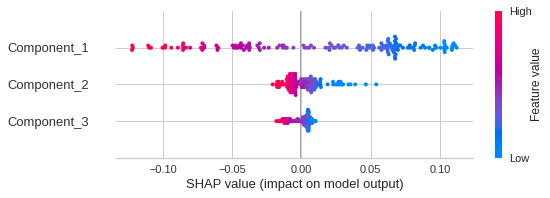

In [ ]:
interpret_model(tuned_et_pca, plot='summary')


In [ ]:
interpret_model(tuned_et_pca, plot='reason', observation=32)

In [ ]:
interpret_model(tuned_et_pca, plot='reason')